# Bài thực hành số 1
- Trong phần này chúng ta sẽ thực hành phần Hồi quy tuyến tính và một phương pháp hồi quy dựa trên mẫu là K-NN (K láng giềng gần nhất).
## A. Phương pháp K-Nearest Neighbors 
### Cho bài toán hồi quy tuyến tính 
- Chúng ta cần đi tính trung bình khoảng cách (y_pred) để phân loại được x new sẽ thuộc vào đâu 
### Ví dụ A.1 

In [5]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


    SAT   GPA
0  1714  2.40
1  1664  2.52
2  1760  2.54
3  1685  2.74
4  1693  2.83
               SAT        GPA
count    84.000000  84.000000
mean   1845.273810   3.330238
std     104.530661   0.271617
min    1634.000000   2.400000
25%    1772.000000   3.190000
50%    1846.000000   3.380000
75%    1934.000000   3.502500
max    2050.000000   3.810000


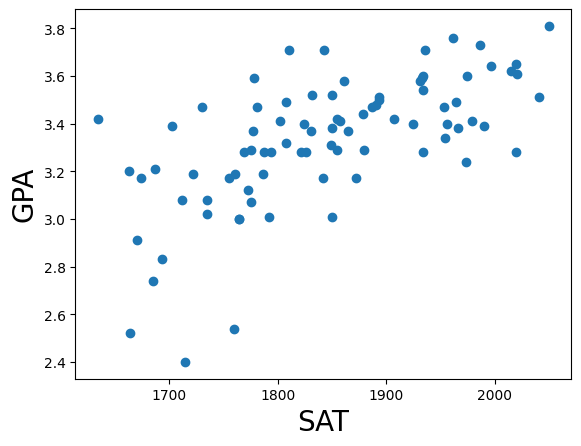

In [2]:
data = pd.read_csv("SAT_GPA.csv")
print(data.head(5))
print(data.describe())

y = data['GPA']
x = data['SAT']

# Bieu do phan tan du lieu 
plt.scatter(x, y)
plt.xlabel("SAT", fontsize = 20)
plt.ylabel("GPA", fontsize = 20)
plt.show()

In [3]:
# Chia tap train test
# Ham tinh khoang cach 
# chon k-cv
X_train = np.array(x[:64])
Y_train = np.array(y[:64])
data_len = len(x)
X_test = np.array(x[64:data_len])
Y_test = np.array(y[64:data_len])
k = 8

def distance(array, value):
    array = np.array(array)
    return abs(array - value)

# ham tim k diem gan nhat
def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    
    # Sap xep theo thu tu tang dan va lay ra 
    # k vi tri dau tien 
    return np.argsort(array_D)[:k]

# Tao mang luu ket qua 
Y_pred = np.zeros(len(X_test))
for i in range(len(X_test)):
    indexis = find_nearest_index(X_train, X_test[i], k)
    for id in indexis:
        Y_pred[i] = Y_pred[i] + Y_train[id]
    Y_pred[i] = Y_pred[i] / len(indexis)
    print(Y_pred[i], "|", Y_test[i])

3.3925000000000005 | 3.51
3.2749999999999995 | 3.52
3.2949999999999995 | 3.52
3.3975000000000004 | 3.54
3.295 | 3.58
3.3974999999999995 | 3.58
3.3975000000000004 | 3.59
3.2587500000000005 | 3.59
3.3899999999999997 | 3.6
3.3975000000000004 | 3.6
3.3874999999999993 | 3.61
3.3874999999999993 | 3.62
3.3662499999999995 | 3.64
3.3874999999999993 | 3.65
3.2950000000000004 | 3.71
3.3975000000000004 | 3.71
3.30875 | 3.71
3.3662500000000004 | 3.73
3.37625 | 3.76
3.3874999999999993 | 3.81


In [11]:
#Tính các độ đo MSE, MAE, R-squared
def print_measure(y_pred, y_true):
    print('MSE: ', np.mean((y_pred - y_true) ** 2))
    print('MAE: ', np.mean(np.abs(y_pred - y_true)))
    print('R - squared: ', 1 - (np.sum((y_pred - y_true) ** 2) / 
          np.sum((y_true - np.mean(y_true)) ** 2)))

In [12]:
# Su dung cac do do MSE, MAE, R-square de danh gia ket qua 
# Co 3 cach danh gia cai nay
# Cach 1: viet ham tung cai 1
# MSE
mse = np.mean((Y_test - Y_pred)**2)
mae = np.mean(abs(Y_test - Y_pred))

y_mean = np.mean(Y_test)
r2 = 1 - np.sum((Y_test - Y_pred)**2) / np.sum((Y_test - y_mean)**2)
print("Mse:", mse)
print("MAE:", mae)
print("r2:", r2)

# Cach 2: su dung thu vien sci,kitlearn cua tung cai mot
mse1 = mean_squared_error(Y_test, Y_pred)
mae1 = mean_absolute_error(Y_test, Y_pred)
r2_1 = r2_score(Y_test, Y_pred)

print("Mse:", mse1)
print("MAE:", mae1)
print("r2:", r2_1)

# Cach 3: tao dataframe va su dung thu vien pandas
df = pd.DataFrame({'Predict': Y_pred, 'True': Y_test})
df.head(5)

print_measure(Y_pred, Y_test)





Mse: 0.08137789062500003
MAE: 0.2711875000000001
r2: -10.951518670142466
Mse: 0.08137789062500003
MAE: 0.2711875000000001
r2: -10.951518670142466
MSE:  0.08137789062500003
MAE:  0.2711875000000001
R - squared:  -10.951518670142466


### Vi du A.2 
(Xem bài giảng lý thuyết phần Hồi quy tuyến tính): Ước lượng áp suất khí quyển (tính theo atm) tại một địa điểm dựa trên nhiệt độ sôi của nước (theo độ F) tại địa điểm đó. Mẫu dữ liệu quan sát từ các thí nghiệm được cho như trong bảng sau)

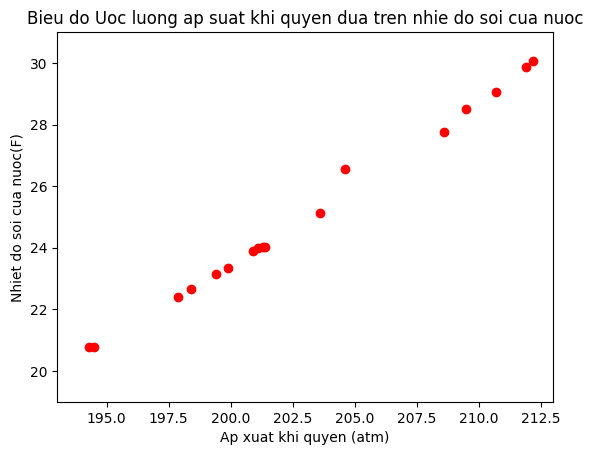

In [64]:
# Temp (F degree)
X = np.array([194.5, 194.3, 197.9, 198.4, 199.4, 199.9, 200.9, 
            201.1, 201.4, 201.3, 203.6, 204.6, 209.5, 208.6, 210.7, 211.9, 212.2]).T

# Press (Atm)
Y = np.array([20.79,20.79,22.4,22.67,23.15,23.35,23.89,23.99,24.02,24.01,25.14,26.57
            ,28.49,27.76,29.04,29.88,30.06]).T

plt.plot(X, Y, 'ro')
plt.title("Bieu do Uoc luong ap suat khi quyen dua tren nhie do soi cua nuoc")
plt.xlabel("Ap xuat khi quyen (atm)")
plt.ylabel("Nhiet do soi cua nuoc(F)")
plt.axis([193, 213, 19, 31])
plt.show()

- Hãy chia dữ liệu thành phần Training gồm 16 mẫu đầu tiên; phần Validation là các mẫu còn lại.
- Chọn k = 4 
- Thực hiện thuật toán K-NN dự đoán các giá trị đầu ra của tập Validation. 
- Đánh giá kết quả dựa trên các độ đo MSE, MAE và R-square

In [65]:
X_train = X[:16]
Y_train = Y[:16]
X_test = X[16:]
Y_test = Y[16:]

k = 4

In [66]:
def distance(array, value):
    array_D = np.array(array)
    return abs(array_D - value)
    
    
def find_NN(array, value, k): 
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]


In [67]:
y_pred = np.zeros(len(X_test))
for i in range(len(X_test)):
    indexes = find_NN(X_train, X_test[i], k)
    for a in  indexes:
        y_pred[i] = y_pred[i] + Y_train[a]
    y_pred[i] = y_pred[i] / len(indexes)
    print(y_pred[i], "|", Y_test[i])





28.7925 | 30.06


In [70]:
df1 = pd.DataFrame({'Predict': y_pred, 'Test': Y_test})
df1.head(5)


,Predict,Test
0,28.7925,30.06


In [74]:
print_measure(y_pred, Y_test)

MSE:  1.6065562499999957
MAE:  1.2674999999999983
R - squared:  -inf


/tmp/ipykernel_21952/290538107.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  print('R - squared: ', 1 - (np.sum((y_pred - y_true) ** 2) /


## Vi du A.3
- Trong ví dụ này, ta sử dụng phương pháp K-NN để dự báo mức độ tiêu thụ nhiên liệu trong 50 bang của Hoa Kỳ và quận Columbia và tìm hiểu hiệu ứng của tiêu thụ nhiên liệu đối với thuế xăng của các bang. 
- Các  biến  dự  báo được  sử  dụng  trong  Applied  Linear  Regression,  3rd  edition,  Sanford  Weisberg, Wiley-Interscience, 2005. Dữ liệu được thu thập bởi Cục Đường bộ Hoa Kỳ vào năm 2001 và được cho trong tệp fuel.txt, gồm các trường như sau: 


In [75]:
import math

In [92]:
with open('fuel.txt') as f:
    lines = f.readlines()
    
x_data = []
y_data = [] 
lines.pop(0)

for line in lines:
    splitted = line.replace('\n', '').split(',')
    splitted.pop(0)
    # map chuyen tat ca sang kieu float
    splitted = list(map(float, splitted))
    fuel = 1000 * splitted[1] / splitted[5]
    dlic = 1000 * splitted[0] / splitted[5]
    logMiles = math.log2(splitted[3])
    y_data.append(fuel)
    x_data.append([splitted[-1], dlic, splitted[2], logMiles])
    
    
# Chuyen x, y data sang array
x_data = np.asarray(x_data)
y_data = np.asarray(y_data)

    

- Hãy chia dữ liệu thành phần Training gồm 40 mẫu đầu tiên; phần Validation là các mẫu còn lại.  
- Chọn k = 6 
- Thực hiện thuật toán K-NN dự đoán các giá trị đầu ra của tập Validation. 
- Đánh giá kết quả dựa trên các độ đo MSE, MAE và R-square.

In [93]:
x_train = x_data[:40]
y_train = y_data[:40]
x_test = x_data[40:]
y_test = y_data[40:]

k = 6

def distance(array, value):
    array = np.array(array)
    # axis = 0: ap dung theo cot
    # axis = 1: ap dung theo hang
    return np.linalg.norm(array - value, ord = 2, axis = 0)


def find_KNN(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]



In [94]:
y_pred = np.zeros(len(x_test))
for i in range(len(x_test)):
    indexis = find_KNN(x_train, x_test[i], k)
    for id in indexis:
        y_pred[i] += y_train[id]
    y_pred[i] = y_pred[i] / len(indexis)



In [96]:

result = pd.DataFrame({"Predict":y_pred, "Test":y_test})
result.head(5)


,Predict,Test
0,620.327845,711.733058
1,620.327845,697.052777
2,620.327845,638.231061
3,620.327845,681.100137
4,620.327845,591.499946


In [97]:
print_measure(y_pred, y_test)

MSE:  7641.5764831541455
MAE:  70.01861251545087
R - squared:  -0.25160320573654027


- MSE rat lon, sai so rat manh, chung to du doan lech nhieu so voi gia tri that
- MAE (sai so tuyet doi trung) trung binh du doan sai khoang 70 don vi 
- R2 < 0 mo hinh rat te, te hon ca trung binh 
KL: Mo hinh cho ket qua khong tot, mo hinh hoat dong kem 

# B. Phuong phap hoi quy tuyen tinh 
## Vi du B.1: Hoi quy tuyent tinh 1 chieu 
- Lấy lại dữ liệu như trong Ví dụ A.2 - Ước lượng áp suất khí quyển (tính theo atm) tại một địa điểm dựa trên nhiệt độ sôi của nước (theo độ F) tại địa điểm đó (Xem bài giảng lý thuyết):  
- Viết chương trình để xây dựng công thức hồi quy tuyến tính cho mối liên hệ giữa nhiệt độ và áp suất. 

a. Tính toán trực tiếp theo công thức cho trường hợp riêng hồi quy đơn, một biến. 
- Trung bình cộng của X: 𝑥̅ =202.9529412 ; Trung bình cộng của Y: 𝑦̅ =25.05882353; 
- Phương sai SXX = 530.7823529; Hiệp phương sai SXY = 277.5420588. 

b. Chương trình Python 
- Khởi tạo dữ liệu (sau đó vẽ ra để hình dung dữ liệu) – Xem trong Ví dụ A.2. 


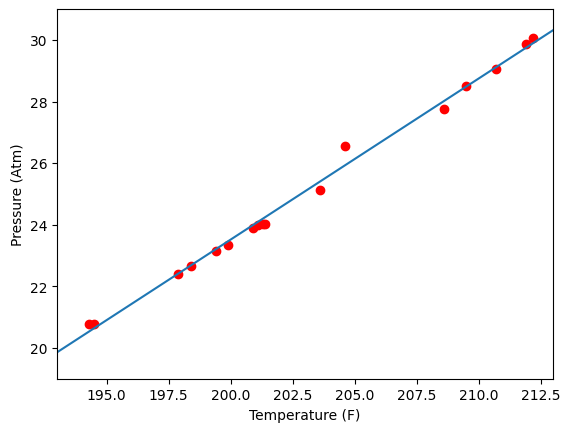

In [102]:
#Nhiệt độ (đo bằng F)
X = np.array([[194.5, 194.3, 197.9, 198.4, 199.4, 199.9, 200.9, 201.1, 201.4, 201.3, 203.6,
               204.6, 209.5, 208.6, 210.7, 211.9, 212.2]]).T
#Áp suất (atm)
y = np.array([[20.79, 20.79, 22.4, 22.67, 23.15, 23.35, 23.89, 23.99, 24.02, 24.01, 25.14, 26.57,
               28.49, 27.76, 29.04, 29.88, 30.06]]).T

#Xây dựng cột X
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

#Tính các trọng số của phương trình hồi quy tuyến tính
# Nhan 2 ma tran 
# A: X^T * X
A = np.dot(Xbar.T, Xbar)
# B: X^T * y
b = np.dot(Xbar.T, y)
# Gia nghich dao boi pinv(A)
w = np.dot(np.linalg.pinv(A), b)

w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(193, 213, 2)
y0 = w_0 + w_1 * x0

#Vẽ đường thẳng hồi quy
plt.plot(X.T, y.T, 'ro')
plt.plot(x0, y0)
plt.axis([193, 213, 19, 31])
plt.xlabel('Temperature (F)')
plt.ylabel('Pressure (Atm)')
plt.show()

## Vi du B.2: Hoi quy tuyen tinh nhieu chieu 
- Trong ví dụ này, ta sử dụng mô hình hồi quy tuyến tính để dự báo 
mức độ tiêu thụ nhiên liệu trong 50 bang của Hoa Kỳ và quận Columbia và tìm hiểu hiệu ứng của tiêu thụ nhiên liệu đối với thuế xăng của các bang. 
- Các biến dự báo được có trong tệp như được mô tả trong Ví dụ A.3. Lưu ý trong mô hình chúng ta vẫn sử dụng một số thuộc tính quy đổi

In [148]:
import math
import numpy as np

with open('fuel.txt') as f:
    lines = f.readlines()

x_data = []
y_data = []
lines.pop(0)

for line in lines:
    splitted = line.replace('\n', '').split(',')
    splitted.pop(0)
    splitted = list(map(float, splitted))
    fuel = 1000 * splitted[1] / splitted[5]
    dlic = 1000 * splitted[0] / splitted[5]
    logMiles = math.log2(splitted[3])
    y_data.append([fuel])
    x_data.append([splitted[-1], dlic, splitted[2], logMiles])

x_data = np.asarray(x_data)
y_data = np.asarray(y_data)

a, Truong hop su dung thu vien numpy 

In [127]:
# TH su dung thu vien numpy 
# Thuat toan HoldHouse 

def qr_householder(A):
    # Tinh so chieu cua 
    M = A.shape[0]
    N = A.shape[1]
    
    # Cai dat ma tran Q la ma tran don vi 
    Q = np.identity(M)
    # cai dat R copy tu A
    R = np.copy(A)
    
    for n in range(N):
        x = A[n:, n]
        k = x.shape[0]
        
        # Tinh ro = -sign(xo)||x|| (ham dau cua x)
        ro = -np.sign(x[0]) * np.linalg.norm(x)
        
        # Tao vector house hold 
        e = np.zeros(k)
        e[0] = 1
        v = (1 / (x[0] - ro) * (x - (ro * e))) # v la vector tao phan xa
        
        # ap dung v cho moi cot cua A de tao R
        for i in range(N):
            R[n:, i] = R[n:, i] - (2 / (v@v)) * ((np.outer(v, v)) @ R[n:, i])

        for i in range(M):
            Q[n:, i] = Q[n:, i] - (2 / (v@v)) * ((np.outer(v, v)) @ Q[n:, i])
        
    return Q.transpose(), R

    
    

In [123]:
# ham hoi quy tuyen tinh 
def linear_regression(x_data, y_data):
    """ 
#    This function calculate linear regression base on x_data and y_data 
#    :param x_data: vector 
#    :param y_data: vector 
#    :return: w (regression estimate) 
#    """ 

    x_bars = np.concatenate((np.ones((x_data.shape[0], 1)), x_data), axis = 1)
    Q, R = qr_householder(x_bars)
    R_pinv = np.linalg.pinv(R) # tinh invers matrix of R
    A = np.dot(R_pinv, Q.T)
    
    return np.dot(A, y_data)
    

In [128]:
w = linear_regression(x_data, y_data)  # get result 
w = w.T.tolist() 

line = ['Intercept', 'Tax', 'Dlic', 'Income', 'LogMiles']
res = list(zip(line, w[0]))
for o in res:
    print("{: >20}: {: >10}".format(*o))

           Intercept: 154.1928445773102
                 Tax: -4.227983208329619
                Dlic: 0.47187121344198124
              Income: -0.006135330970417609
            LogMiles: 18.54527450604798


b, Truong hop su dung thu vien Sciki-Learn 

In [158]:
from sklearn import datasets, linear_model 
# Load training data here and assign to Xbar (obs. Data) and y (label) 
# fit the model by Linear Regression
regr = linear_model.LinearRegression(fit_intercept = True)
# fit_intercept = False for calculating the bias 
regr.fit(x_data, y_data)

intercept = regr.intercept_.ravel()
cofficients = regr.coef_.ravel()

line = ['Intercept', 'Tax', "Dlic", "Income", "LogMiles"]
res = list(zip(line, np.concatenate((intercept, cofficients))))

for name, value in res:
    print(f"{name:>20} : {value:>10}")


           Intercept : 154.19284457730458
                 Tax : -4.227983208329685
                Dlic : 0.4718712134419861
              Income : -0.006135330970417732
            LogMiles : 18.545274506048024


## Bai tap B.1 
- Sử dụng 40 mẫu trong tập dữ liệu của ví dụ 2 (coi là tập training) để huấn luyện các 
đoạn chương trình đã có, sau đó dự đoán đầu ra với các mẫu dữ liệu còn lại (coi là tập validation). 
Hãy dùng các độ đo sau đây để đánh giá độ chính xác của mô hình trên các tập training và validation: 
MSE; MAE; R-square.

In [ ]:
import math
import numpy as np

with open('fuel.txt') as f:
    lines = f.readlines()

x_data = []
y_data = []
lines.pop(0)

for line in lines:
    splitted = line.replace('\n', '').split(',')
    splitted.pop(0)
    splitted = list(map(float, splitted))
    fuel = 1000 * splitted[1] / splitted[5]
    dlic = 1000 * splitted[0] / splitted[5]
    logMiles = math.log2(splitted[3])
    y_data.append([fuel])
    x_data.append([splitted[-1], dlic, splitted[2], logMiles])

x_data = np.asarray(x_data)
y_data = np.asarray(y_data)

In [165]:
#Tập training
x_train = np.array(x_data[:40])
y_train = np.array(y_data[:40])

#Tập validation
x_valid = np.array(x_data[40:])
y_valid = np.array(y_data[40:])

#Dự đoán đầu ra
y_train_pred = regr.predict(x_train)
y_valid_pred = regr.predict(x_valid)

df = pd.DataFrame({'Predict': y_valid_pred.flatten(), 'True': y_valid.flatten()})
df.index = df.index + 1
print(df)

       Predict        True
1   666.001135  711.733058
2   649.575323  697.052777
3   657.729032  638.231061
4   630.279521  681.100137
5   630.453962  591.499946
6   667.961262  691.022712
7   607.702966  681.031121
8   605.146291  576.069750
9   619.709317  562.410933
10  593.122318  581.793717
11  659.292991  842.791752


In [166]:
mse_train = mean_squared_error(y_train, y_train_pred)
mse_valid = mean_squared_error(y_valid, y_valid_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_valid = mean_absolute_error(y_valid, y_valid_pred)

r2_train = r2_score(y_train, y_train_pred)
r2_valid = r2_score(y_valid, y_valid_pred)

print("TRAINING SET")
print("MSE :", mse_train)
print("MAE :", mae_train)
print("R2  :", r2_train)

print("\nVALIDATION SET")
print("MSE :", mse_valid)
print("MAE :", mae_valid)
print("R2  :", r2_valid)

TRAINING SET
MSE : 3525.916131951753
MAE : 44.47151308039231
R2  : 0.5272755291573565

VALIDATION SET
MSE : 4787.579081043687
MAE : 52.73398823301323
R2  : 0.21584906743246368


### Danh gia do chinh xac mo hinh 
- Chỉ số $R^2$ (Độ phù hợp) - "Điểm yếu chí mạng"Training $R^2 \approx 0.53$: Mô hình giải thích được khoảng 53% sự biến thiên của dữ liệu tập huấn luyện. Đây là một con số trung bình, không quá cao nhưng cũng không quá tệ.Validation $R^2 \approx 0.22$: Khi sang tập kiểm định, con số này tụt dốc thảm hại xuống còn 22%.Đánh giá: Khoảng cách (Gap) giữa 0.53 và 0.22 quá lớn. Điều này khẳng định mô hình không có khả năng tổng quát hóa (generalization) tốt.MSE và MAE (Sai số)MAE tăng từ 44.47 lên 52.73: Sai số tuyệt đối trung bình ở tập Validation cao hơn Training khoảng 18.5%.MSE tăng từ 3526 lên 4788: Sai số bình phương trung bình ở tập Validation cao hơn đáng kể. Vì MSE phóng đại các sai số lớn, điều này cho thấy trên tập Validation có nhiều điểm dữ liệu bị dự báo sai lệch rất nặng (outliers).
- Kết luận: Mô hình hiện tại chưa đạt yêu cầu để sử dụng thực tế.Độ chính xác thấp: Ngay cả trên tập Training, $R^2 = 0.53$ cho thấy mô hình vẫn còn khá "ngây ngô", chưa bắt được hết các quy luật của dữ liệu (có dấu hiệu nhẹ của Underfitting ở bước đầu).Khả năng tổng quát kém: Việc chỉ số tụt mạnh ở Validation cho thấy mô hình đang bị nhiễu (noise) làm phiền.

## Vi du B.3 (Bai tap thuc hanh 1)
Sử dụng lại tệp dữ liệu cũng như đoạn lệnh đọc dữ liệu từ Ví 
dụ A.1. Tuy nhiên trong bài tập này các bạn cần xây dựng mô hình Hồi quy tuyến tính để dự đoán. 
Thực hiện các yêu cầu sau đây: 
- (i) Sử dụng hệ số tương quan Pearson correlative để đánh giá mức độ phụ thuộc của đầu ra 
(GPA) với đầu vào (SAT). 
- (ii) Hãy chia dữ liệu thành phần training với 64 mẫu đầu và validation với các mẫu còn lại. 
- (iii) Tham  khảo  các  ví  dụ  trước, sau đó lập  công  thức  hồi  quy  tuyến  tính  ứng  với  dữ  liệu 
training nói trên. Hiển  thị đồ thị của đường hồi quy với các điểm dữ liệu đã vẽ ở phần 
code đã cho. 
- (iv) Chạy thử mô hình với dữ liệu validation và tính các độ đo đánh giá sau: MSE; MAE; R-
square.  
- (v) So sánh kết quả này với kết quả sử dựng phương pháp K-NN (K-Nearest Neighbors) trong 
Ví dụ A.1.

In [171]:
# Lay du lieu, chia train test
data = pd.read_csv("SAT_GPA.csv")
data.head(5)

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


In [186]:
#tap train
x_train = np.array((data["SAT"])[:64]).reshape(-1, 1)
y_train = np.array((data["GPA"])[:64])

#tap test
x_validation = np.array((data["SAT"])[64:]).reshape(-1, 1)
y_validation = np.array((data["GPA"])[64:])

In [ ]:
# Su dung he so tuong quan cor de danh gia muc do phu thuoc (quan he tuyen tinh
# giua gpa va sat
gpa = data["GPA"]
sat = data["SAT"]


In [208]:
# Su dung cong thuc cor 
x = np.array(sat)
y = np.array(gpa)

x_mean = np.mean(x)
y_mean = np.mean(y) 

tuso = np.sum((x - x_mean) * (y - y_mean))
mauso = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))

cor = tuso / mauso
print("Person correlative:", cor)

Person correlative: 0.6371843648401909


In [174]:
# su dung thu vien np 
r = np.corrcoef(sat, gpa)[0, 1]
print("Pearson correlative:", r)

Pearson correlative: 0.6371843648401915


- ta thay r > 0.5 va r < 0.8 cho thay muc do tuong quan giua bien sat va gpa la tuong doi tot 

In [193]:
# lap mo hinh hoi quy tuyen tinh
# su dung thu vien scikit learn 
model = linear_model.LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_validation)

intercept = model.intercept_.ravel()
coefficients = model.coef_.ravel()

In [211]:
# Ve do thi cua duong hoi quy tuyen tinh 
t0 = intercept
t1 = coefficients
x0 = np.linspace(1600, 2100, 10)
res = np.concatenate((t0, t1))

for name, value in zip(['Intercept', 'SAT'], res):
    print(f"{name:}: {value:}")



Intercept: 0.8382097630766756
SAT: 0.0013183893573835055


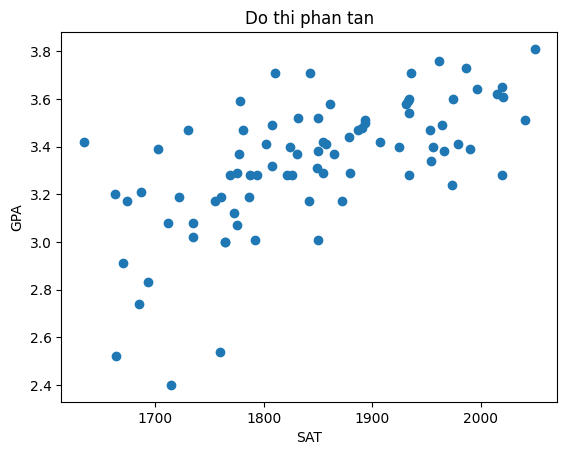

In [205]:

plt.scatter(x, y)
plt.title("Do thi phan tan")
plt.xlabel("SAT")
plt.ylabel("GPA")
plt.show()

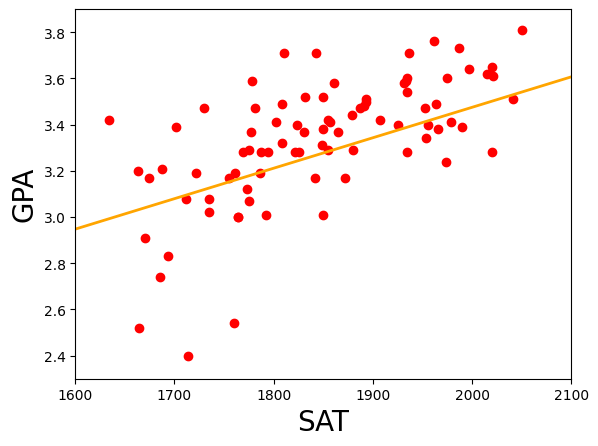

In [214]:
y0 = t1 * x0 + t0
plt.plot(x, y, 'ro')
fig = plt.plot(x0, y0, lw = 2, c = 'orange', label = 'regression line')
plt.xlabel("SAT", fontsize = 20)
plt.axis([1600, 2100, 2.3, 3.9])
plt.ylabel("GPA", fontsize = 20)
plt.show()


In [221]:
# Chay thu mo hinh voi du lieu validation, tinh cac do do 
# chay
result = pd.DataFrame({"Validation" : y_validation, "Pred" : y_pred})
result.index = result.index + 1
print(result.head(5))

MSE = mean_squared_error(y_validation, y_pred)
MAE = mean_absolute_error(y_validation, y_pred)
R2 = r2_score(y_validation, y_pred)
        
print(f"MSE: {MSE}")
print(f"MAE: {MAE}")
print(f"R_square: {R2}")

   Validation      Pred
1        3.51  3.333921
2        3.52  3.253499
3        3.52  3.277230
4        3.54  3.387975
5        3.58  3.291732
MSE: 0.07263824293181359
MAE: 0.24880371695218736
R_square: -9.667975169894788


### nxet
- co the thay mse, va mae o muc chap nhan duoc, mse thap do gpa < 4, con mse thap o muc 24%. Ket qua cho thay kha thi hon mo hinh KNN phan loai, tuy nhien voi r2 < 0 => mo hinh dang fit du lieu sai, model te hon ca viec doan trung binh gpa 

## Vi du B.4 (Bai tap 2):
- Trong y sinh học, bề dày lớp nội trung mạc (NTM) phản ánh một số bệnh lý 
của cơ thể. Thực tế hiện tượng dày lớp NTM động mạch cảnh do nhiều yếu tố như di truyền, chủng 
tộc, mắc bệnh tim mạch, tuổi, giới, BMI, tăng huyết áp, đái tháo đường.... cùng tác động. Trong ví 
dụ này ta không đề cập các yếu tố di truyền, chủng tộc, giới, mắc bệnh tim mạch... mà chỉ lưu ý đến 
các biến số như: tuổi, cholesterol, glucose, huyết áp tâm thu và BMI tác động lên độ dày NTM.

- Hãy dùng dữ liệu cho trong tệp vidu4_lin_reg.txt (tệp văn bản) để xây dựng mô hình hồi quy tuyến 
tính cho thấy sự phụ thuộc của bề dày lớp NTM theo các biến số khác. Tham khảo phần đọc dữ liệu 
từ tệp văn bản đã có trong ví dụ trước. Các trường dữ liệu gồm: 

- Mô hình cần xây dựng có dạng: 
Bề dày NTM= 0 + 1(tuổi) + 2(cholesterol) + 3(glucose) + 4(huyết áp TT) + 5(BMI)
- a) Xác định các hệ số với 100 dữ liệu trên
- b) Chia dữ liệu thành: 80 dòng đầu dùng cho training; 20 dòng sau dùng cho testing. Tính lại các hệ số 
với bộ dữ liệu này, sau đó chạy thử trên bộ dữ liệu test và tính các đại lượng kỳ vọng, phương sai của 
sai số.

In [243]:
# doc du lieu 
with open("vidu4_lin_reg.txt") as f:
    lines = f.readlines()

data = []
header = np.array(lines.pop(0).split())
for line in lines:
    value = [float(x) for x in line.split()]
    data.append(value)
data_array = np.array(data)

print(header)


['ID' 'TUOI' 'BMI' 'HA' 'GLUCOSE' 'CHOLESTEROL' 'BEDAYNTM']


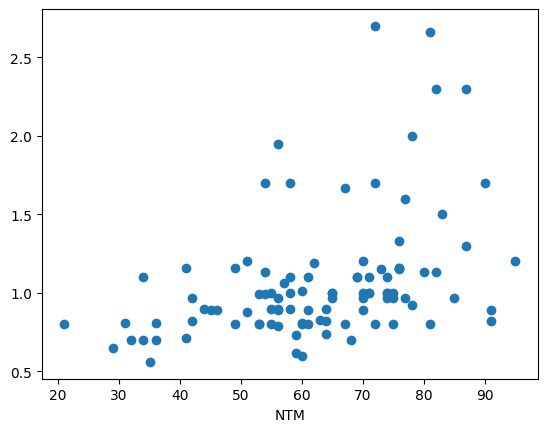

In [269]:
# Xay dung mo hinh hqtt
x = np.column_stack((
    data_array[:, 1],
    data_array[:, 5],
    data_array[:, 4],
    data_array[:, 3],
    data_array[:, 2]
))
y = data_array[:, 6]

x_train = np.array(x[:80])
y_train = np.array(y[:80])
x_test = np.array(x[80:])
y_test = np.array(y[80:])

plt.scatter(x[:, 0], y)
plt.xlabel("Tuoi")
plt.xlabel("NTM")
plt.show()


In [277]:
# Mo hinh hqtt
model = linear_model.LinearRegression()
names = np.array([
    header[1], 
    header[5],
    header[4],
    header[3],
    header[2]
])
names = np.concatenate((["Intercept"], names))

print(names)
# Voi bo du lieu 100 mau 
def print_model(names, intercept, coef):
    equation = "NTM = "
    icept = intercept[0]
    # intercept
    equation += f"{icept:.6f}"
    
    # các hệ số
    for name, c in zip(names[1:], coef):
        if c >= 0:
            equation += f" + {c:.6f}*{name}"
        else:
            equation += f" - {abs(c):.6f}*{name}"
    
    print(equation)
    
def models(x, y): 
    model.fit(x, y)
    intercept = model.intercept_.ravel()
    coefficient = model.coef_.ravel()
    print(coefficient)
    res = np.concatenate((intercept, coefficient))

    for name, value in zip(names, res):
        print(f"{name:} : {value:}")
    
    print_model(names, intercept, coefficient)
        



['Intercept' 'TUOI' 'CHOLESTEROL' 'GLUCOSE' 'HA' 'BMI']


In [278]:
print("Voi bo du lieu 100")
models(x, y)

Voi bo du lieu 100
[ 0.00994694  0.03847025  0.0076701   0.00218137 -0.00020655]
Intercept : -0.10802908119387089
TUOI : 0.00994694094710986
CHOLESTEROL : 0.038470248239703464
GLUCOSE : 0.007670101694230001
HA : 0.002181366945247517
BMI : -0.00020654770133402163
NTM = -0.108029 + 0.009947*TUOI + 0.038470*CHOLESTEROL + 0.007670*GLUCOSE + 0.002181*HA - 0.000207*BMI


In [281]:
print("voi bo du lieu train test")
models(x_train, y_train)
y_pred = model.predict(x_test)

residuals = y_test - y_pred

# Tính kỳ vọng của sai số
mean_residuals = np.mean(residuals)

# Tính phương sai của sai số
variance_residuals = np.var(residuals)

print(f"Kỳ vọng của sai số là: {mean_residuals}")
print(f"Phương sai của sai số là: {variance_residuals}")


voi bo du lieu train test
[ 0.0089892   0.00708535  0.00808634  0.00260218 -0.00047742]
Intercept : 0.04306436410329684
TUOI : 0.008989196889296789
CHOLESTEROL : 0.00708535234192379
GLUCOSE : 0.008086342231978145
HA : 0.002602179867555774
BMI : -0.00047742422185274267
NTM = 0.043064 + 0.008989*TUOI + 0.007085*CHOLESTEROL + 0.008086*GLUCOSE + 0.002602*HA - 0.000477*BMI
Kỳ vọng của sai số là: 0.07998861696197092
Phương sai của sai số là: 0.22100281283267012


## Vi du B.5 (Bai tap 3): 
- Trong tệp dữ liệu Real_estate.csv đính kèm chứa thông tin các giao dịch mua 
bán bất động sản. Chúng ta có 414 mẫu dữ liệu, mỗi bản ghi có 8 cột theo thứ tự là
- Cột x1: Số thứ tự (chúng ta sẽ bỏ qua trường này) 
- • Cột x2: Ngày giao dịch mua bán (ta chỉ lấy phần nguyên là năm) 
- • Cột x3: Tuổi của căn nhà (theo năm) 
- • Cột x4: Khoảng cách tới ga MRT (phương tiện công cộng nội đô) gần nhất   
- • Cột x5: Số cửa hàng tiện ích gần đó 
- • Cột x6: Kinh độ căn nhà; Cột X7: Vĩ độ căn nhà; 
- • Cột Y (đầu ra dự báo): Giá của căn nhà
- Hãy chia dữ liệu thành phần training với 350 mẫu đầu tiên, phần validation với số mẫu còn lại. Hãy tham 
khảo các bài trên và xây dựng mô hình hồi quy tuyến tính mô tả sự phụ thuộc của Y vào các cột từ X2 đến 
X6. Sau đó hãy chạy dự đoán cho phần dữ liệu validation và đưa ra tổng bình phương sai số của dự đoán. 
- So sánh với phương pháp K-NN, lấy K = 18.

In [294]:
data = pd.read_csv("real_estate.csv")
data["Year"] = data["X1 transaction date"].astype(int)
print(data.info())
print(data.head(5))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 9 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
 8   Year                                    414 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 29.2 KB
None
   No  X1 transaction date  X2 house age  \
0   1             2012.917          3

In [303]:
x = np.array(data.iloc[:, [-1,3,4,5,6]])
y = np.array(data.iloc[:, 7])

x_train = np.array(x[:350])
y_train = np.array(y[:350])
x_test = np.array(x[350:])
y_test = np.array(y[350:])

# xay dung mo hinh, chi ra su phu thuoc cua y vao x,
model = linear_model.LinearRegression()
model.fit(x_train, y_train)

intercept = model.intercept_.ravel()
coef = model.coef_.ravel()
res = np.concatenate((intercept, coef))
names = ["Intercept", "x2", "x3", "x4", "x5", "x6"]

for name, value in zip(names, res):
    print(f"{name:} : {value:}")
    
print_model(names, intercept, coef)


# danh gia
# du doan cho tap validation, dua ra tong binh phuong sai so
y_pred = model.predict(x_test)

pred = pd.DataFrame({
    "Validation" : y_test ,
    "Pred" : y_pred}
)

print(pred.head(5))
print("==== Linear Regression ===")
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("mse:", mse)
print("mae:", mae)
print("r2:", r2)

error = y_test - y_pred
sse = np.sum(error**2)
print("Tong binh phuong sai so:", sse)



Intercept : -11444.117959447938
x2 : 2.3586863508653844
x3 : -0.004114962885960822
x4 : 1.1275517755877973
x5 : 247.53838440190665
x6 : 4.556674828398122
NTM = -11444.117959 + 2.358686*x2 - 0.004115*x3 + 1.127552*x4 + 247.538384*x5 + 4.556675*x6
   Validation       Pred
0        42.3  41.169082
1        28.6  29.022646
2        25.7  26.519998
3        31.3  31.456661
4        30.1  29.892590
==== Linear Regression ===
mse: 69.11117654161484
mae: 6.299397526157128
r2: 0.5669468686571137
Tong binh phuong sai so: 4423.11529866335


In [296]:
from sklearn.neighbors import KNeighborsRegressor

# Xay dung mo hinh KNN 4
print("\n=== KNN (k = 18) ===")
knn = KNeighborsRegressor(n_neighbors=18)
knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)

pred_knn = pd.DataFrame({
    "Validation" : y_test ,
    "Pred" : y_pred_knn}
)

print(pred_knn.head(5))

print("MSE:", mean_squared_error(y_test, y_pred_knn))
print("MAE:", mean_absolute_error(y_test, y_pred_knn))
print("R2 :", r2_score(y_test, y_pred_knn))


=== KNN (k = 18) ===
   Validation       Pred
0        42.3  39.427778
1        28.6  27.177778
2        25.7  26.722222
3        31.3  27.177778
4        30.1  28.994444
MSE: 44.77186005015431
MAE: 5.033246527777778
R2 : 0.7194579059279929


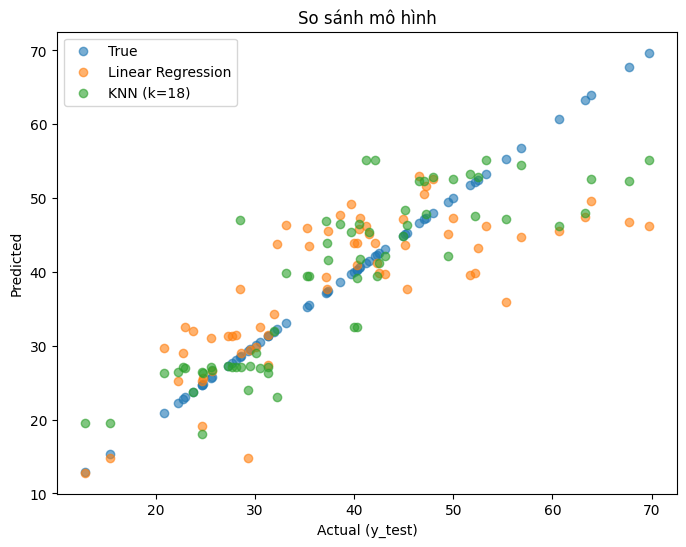

In [301]:
# Ve bieu do danh gia 2 mo hinh 
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test, label = "True", alpha = 0.6)
# hồi quy tuyến tính
plt.scatter(y_test, y_pred, label="Linear Regression", alpha=0.6)

# KNN
plt.scatter(y_test, y_pred_knn, label="KNN (k=18)", alpha=0.6)

plt.xlabel("Actual (y_test)")
plt.ylabel("Predicted")
plt.title("So sánh mô hình")
plt.legend()
plt.show()

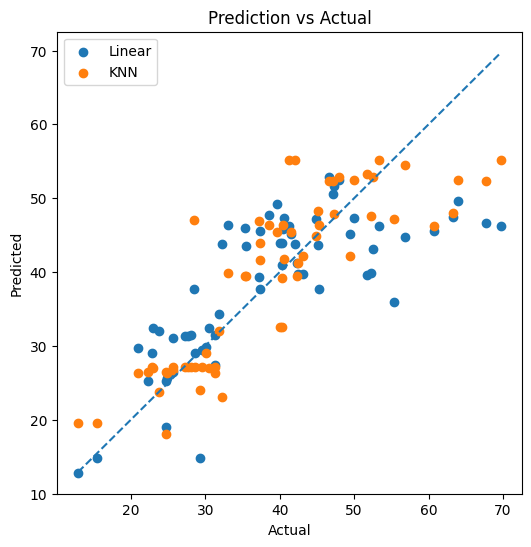

In [302]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, label="Linear")
plt.scatter(y_test, y_pred_knn, label="KNN")

# đường y = x (perfect prediction)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.title("Prediction vs Actual")
plt.show()

### Nhan xet
- Doi voi mo hinh Linear Regression, mse cao, mae cao, r2 o muc trung binh, mo hinh ly giai duoc 56,7% du lieu
- Doi voi mo hinh KNN voi k = 18, co the thay su khac biet ro ret, mse thap hon, mae thap hon, r2 cao > 0.7, mo hinh tot hon Linear regresson

- Vay mo hinh knn phu hop hon voi tap du lieu nay
- nguyen nhan co the moi quan he giua cac bien trong du lieu khong mang tinh tuyen tinh